In [243]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import torch
from torch import nn, optim
from torch.nn import functional as F
from torch.optim import lr_scheduler
from torch.utils.data import Dataset, DataLoader
from pytorch_generative import models
from tqdm import tqdm
from scipy import stats, fft
from scipy.spatial.distance import euclidean, cosine
from scipy.stats import wasserstein_distance, ks_2samp, entropy
from scipy.special import kl_div
from time import time
from datetime import timedelta
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

init_time = time()

Using device: cuda


In [244]:
from apafib import load_MITBIH

df_mitbih = load_MITBIH()
df_normal = df_mitbih[df_mitbih['target'] == 'Normal'].copy()

signal_columns = [col for col in df_normal.columns if col != 'target']
X_normal_original = df_normal[signal_columns].values

# Añadir padding
zeros_padding = np.zeros((X_normal_original.shape[0], 2))
X_normal = np.concatenate([X_normal_original, zeros_padding], axis=1)

print(f"Dataset: {len(df_normal)} señales normales, longitud: {X_normal.shape[1]}")

Dataset: 7263 señales normales, longitud: 96


In [245]:
class ECGPreprocessor:    
    def __init__(self, window_size, vocab_size, overlap=0):
        self.window_size = window_size
        self.vocab_size = vocab_size
        self.overlap = overlap
        self.gmm = None
        self.centroids = None
        # NUEVO: Añadimos el scaler
        self.scaler = MinMaxScaler(feature_range=(-1, 1)) 
        
    def fit_gmm(self, signals):
        # 1. Primero ajustamos el scaler con todas las señales
        # Aplanamos para fit y luego volvemos a la forma original
        flat_signals = signals.flatten().reshape(-1, 1)
        self.scaler.fit(flat_signals)
        
        # 2. Normalizamos las señales antes de ventanear
        signals_norm = self.scaler.transform(flat_signals).reshape(signals.shape)
        
        # 3. Creamos ventanas con señal normalizada
        windows = self.create_windows(signals_norm)
        
        # 4. Entrenamos GMM
        all_values = windows.flatten().reshape(-1, 1)
        self.gmm = GaussianMixture(n_components=self.vocab_size, covariance_type='full', 
                                    random_state=42, max_iter=100)
        self.gmm.fit(all_values)
        self.centroids = self.gmm.means_
        
        print(f"GMM entrenado. Centroides min: {self.centroids.min():.4f}, max: {self.centroids.max():.4f}")

    def create_windows(self, signals):
        # Nota: Asegúrate de pasar señales YA normalizadas si las usas fuera de fit_gmm
        # O normaliza dentro si son datos nuevos.
        windows = []
        stride = self.window_size - self.overlap
        for signal in signals:
            n_windows = (len(signal) - self.window_size) // stride + 1
            for i in range(n_windows):
                start = i * stride
                end = start + self.window_size
                if end <= len(signal):
                    windows.append(signal[start:end])
        return np.array(windows)
    
    def discretize_windows(self, windows):
        # El GMM espera datos de la misma escala con la que fue entrenado.
        # Asumimos que 'windows' ya viene de señales normalizadas.
        b, w = windows.shape
        flat = windows.reshape(-1, 1)
        labels = self.gmm.predict(flat)
        return labels.reshape(b, w)
    
    def reconstruct_signal(self, discrete_signal):        
        # Reconstruimos los valores normalizados
        reconstructed_norm = self.centroids[discrete_signal].reshape(-1, 1)
        # Deshacemos la normalización para volver a mV reales
        return self.scaler.inverse_transform(reconstructed_norm).flatten()

def split_dataset(X, train_ratio=0.5, val_ratio=0.25, test_ratio=0.25):
    X_train, X_temp = train_test_split(X, test_size=(val_ratio + test_ratio), random_state=42)
    val_fraction = val_ratio / (val_ratio + test_ratio)
    X_val, X_test = train_test_split(X_temp, test_size=(1 - val_fraction), random_state=42)
    return X_train, X_val, X_test

GMM entrenado. Centroides min: -0.8589, max: 0.8665
Train: 14526 ventanas | Val: 7260 | Test: 7266
Train: 14526 ventanas | Val: 7260 | Test: 7266


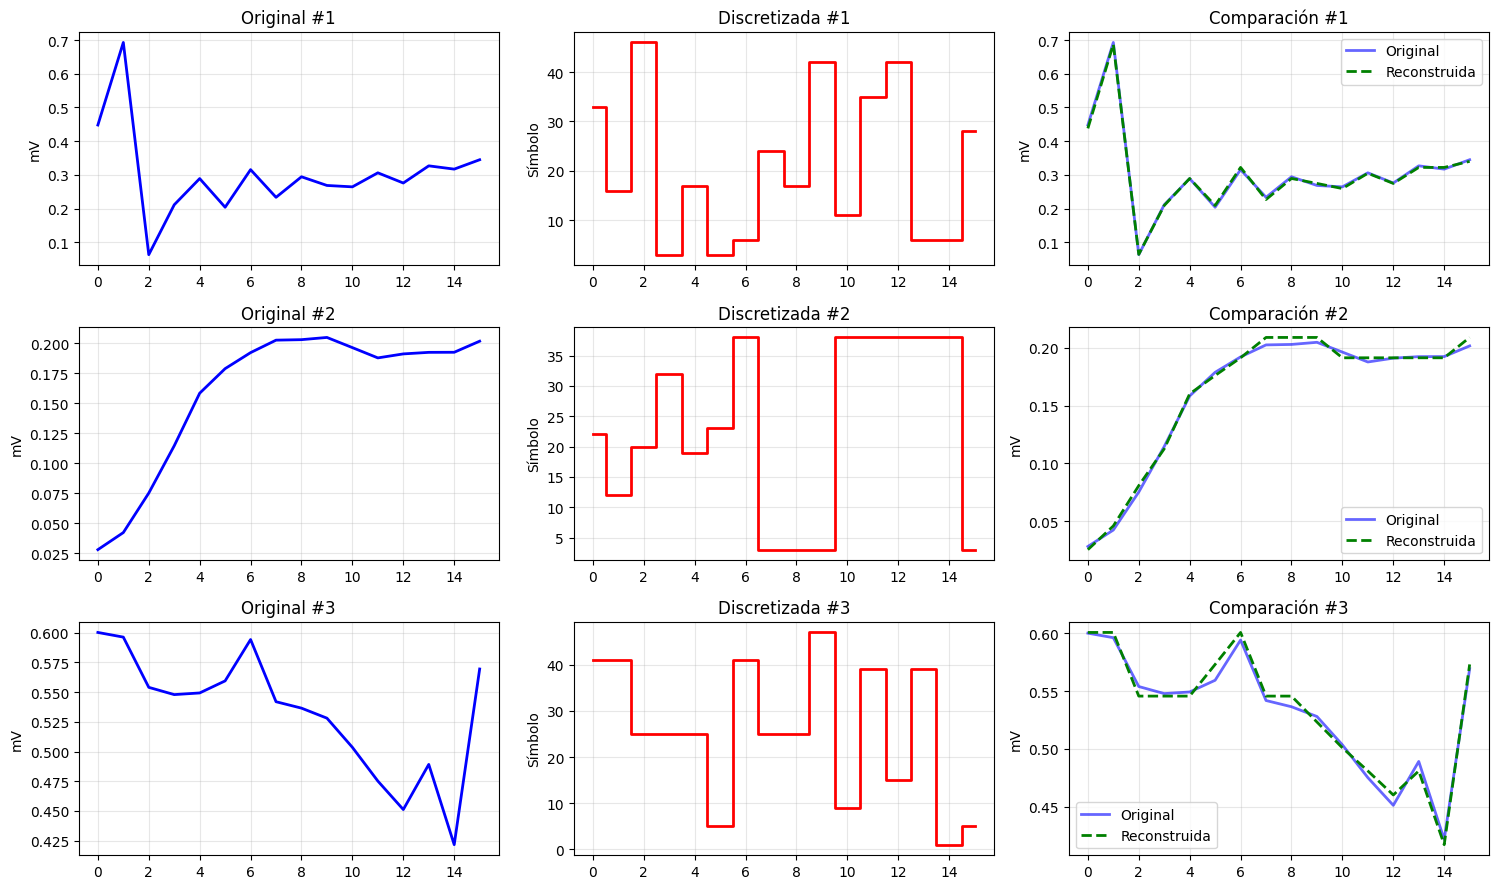

In [246]:
# PARÁMETROS OPTIMIZADOS PARA MEJOR GENERACIÓN
WINDOW_SIZE = 16  # REDUCIDO MÁS: 32 → 16 (más fácil de aprender)
VOCAB_SIZE = 48   # REDUCIDO: 64 → 48 (menos complejidad)

X_for_gmm, X_remaining = train_test_split(X_normal, test_size=2/3, random_state=42)

preprocessor = ECGPreprocessor(window_size=WINDOW_SIZE, vocab_size=VOCAB_SIZE) 
preprocessor.fit_gmm(X_for_gmm)

def normalize_and_window(X_data, prep):
    shape = X_data.shape
    X_norm = prep.scaler.transform(X_data.flatten().reshape(-1, 1)).reshape(shape)
    return prep.create_windows(X_norm)

# Split y crear ventanas normalizadas
X_train, X_val, X_test = split_dataset(X_remaining, 0.5, 0.25, 0.25)
windows_train = normalize_and_window(X_train, preprocessor)
windows_val = normalize_and_window(X_val, preprocessor)
windows_test = normalize_and_window(X_test, preprocessor)

discrete_train = preprocessor.discretize_windows(windows_train)
discrete_val = preprocessor.discretize_windows(windows_val)
discrete_test = preprocessor.discretize_windows(windows_test)

print(f"Train: {len(windows_train)} ventanas | Val: {len(windows_val)} | Test: {len(windows_test)}")

n_examples = 3
fig, axes = plt.subplots(n_examples, 3, figsize=(15, 3*n_examples))
for i in range(n_examples):
    sample_idx = i * (len(windows_train) // n_examples + 1)
    original_window_norm = windows_train[sample_idx]  
    discrete_window = discrete_train[sample_idx]
    reconstructed_window_real = preprocessor.reconstruct_signal(discrete_window)  
    
    original_window_real = preprocessor.scaler.inverse_transform(
        original_window_norm.reshape(-1, 1)
    ).flatten()
    
    axes[i, 0].plot(original_window_real, 'b-', linewidth=2)
    axes[i, 0].set_title(f'Original #{i+1}')
    axes[i, 0].set_ylabel('mV')
    axes[i, 0].grid(True, alpha=0.3)
    
    axes[i, 1].step(range(len(discrete_window)), discrete_window, 'r-', where='mid', linewidth=2)
    axes[i, 1].set_title(f'Discretizada #{i+1}')
    axes[i, 1].set_ylabel('Símbolo')
    axes[i, 1].grid(True, alpha=0.3)
    
    axes[i, 2].plot(original_window_real, 'b-', alpha=0.6, linewidth=2, label='Original')
    axes[i, 2].plot(reconstructed_window_real, 'g--', linewidth=2, label='Reconstruida')
    axes[i, 2].set_title(f'Comparación #{i+1}')
    axes[i, 2].set_ylabel('mV')
    axes[i, 2].grid(True, alpha=0.3)
    axes[i, 2].legend()

plt.tight_layout()
plt.show()


## Dataset y DataLoader para Entrenamiento

In [247]:
class ECGWindowDataset(Dataset):
    def __init__(self, discrete_windows, vocab_size):
        self.discrete_windows = torch.LongTensor(discrete_windows)
        self.vocab_size = vocab_size
        
    def __len__(self):
        return len(self.discrete_windows)
    
    def __getitem__(self, idx):
        discrete_window = self.discrete_windows[idx]
        one_hot = F.one_hot(discrete_window, num_classes=self.vocab_size)
        return one_hot.reshape(-1).float()

BATCH_SIZE = 128

train_dataset = ECGWindowDataset(discrete_train, VOCAB_SIZE)
val_dataset = ECGWindowDataset(discrete_val, VOCAB_SIZE)
test_dataset = ECGWindowDataset(discrete_test, VOCAB_SIZE)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Batches - Train: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")

Batches - Train: 114 | Val: 57 | Test: 57


In [248]:
def loss_fn(x, preds):
    batch_size = x.shape[0]
    x, preds = x.view((batch_size, -1)), preds.view((batch_size, -1))
    loss = F.binary_cross_entropy_with_logits(preds, x, reduction="none")
    return loss.sum(dim=1).mean()

def train_loop(model, optimizer, scheduler, loss_fn, dataloader, epochs, val_loader=None):
    hist_loss = []
    hist_val_loss = []
    pbar = tqdm(range(epochs))
    for epoch in pbar:  # bucle para todos los epochs
        # ENTRENAMIENTO
        model.train()
        running_loss = 0.0
        for i, data in enumerate(dataloader):
            # obtenemos los datos y los subimos a la GPU
            inputs = data.to(device)

            # Reiniciamos los gradientes
            optimizer.zero_grad()

            # Aplicamos los datos al modelo
            outputs = model(inputs)

            # Calculamos la perdida
            loss = loss_fn(inputs, outputs)

            # Hacemos el paso hacia atras
            loss.backward()
            optimizer.step()

            # Vamos guardando la perdida
            running_loss += loss.item()

        epoch_loss = running_loss / (i + 1)
        hist_loss.append(epoch_loss)
        
        # VALIDACIÓN (opcional)
        val_loss_str = ''
        if val_loader is not None:
            model.eval()
            val_loss = 0.0
            with torch.no_grad():
                for j, val_data in enumerate(val_loader):
                    val_inputs = val_data.to(device)
                    val_outputs = model(val_inputs)
                    val_loss += loss_fn(val_inputs, val_outputs).item()
            val_loss = val_loss / (j + 1)
            hist_val_loss.append(val_loss)
            val_loss_str = f' | val: {val_loss:3.4f}'

        if scheduler is not None:
            scheduler.step()
            lr = f' | lr: {scheduler.get_last_lr()[0]:.4E}'
        else:
            lr = ''

        pbar.set_description(f'loss: {epoch_loss:3.4f}{val_loss_str}{lr}')

    if val_loader is not None:
        return hist_loss, hist_val_loss
    return hist_loss

In [249]:
input_dim = WINDOW_SIZE * VOCAB_SIZE
hidden_dims = [256, 256]  # AUMENTADO: 2 capas más grandes
n_masks = 1

made_model = models.MADE(input_dim=input_dim, hidden_dims=hidden_dims, n_masks=n_masks)
made_model.to(device)

optimizer = optim.AdamW(made_model.parameters(), lr=2e-4, weight_decay=1e-3, 
                        betas=(0.9, 0.999), eps=1e-8)
scheduler = lr_scheduler.MultiplicativeLR(optimizer, lr_lambda=lambda _: 0.99999)

print(f"Modelo MADE configurado: {sum(p.numel() for p in made_model.parameters()):,} parámetros")


Modelo MADE configurado: 460,032 parámetros


## Grid Search de Hiperparámetros

  0%|          | 0/200 [00:00<?, ?it/s]

loss: 29.7190 | val: 34.4320 | lr: 1.9960E-04: 100%|██████████| 200/200 [07:15<00:00,  2.18s/it]




Entrenamiento completado
  Train loss final: 29.7190
  Val loss final:   34.4320
  Overfit ratio:    1.16x


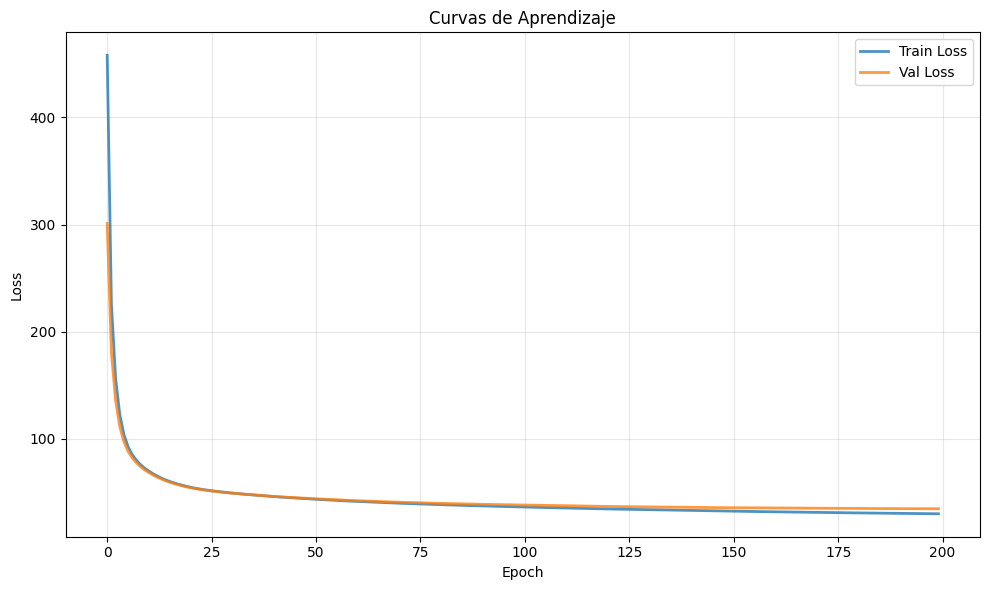

In [250]:
EPOCHS = 200
train_losses, val_losses = train_loop(
    model=made_model,
    optimizer=optimizer,
    scheduler=scheduler,
    loss_fn=loss_fn,
    dataloader=train_loader,
    epochs=EPOCHS,
    val_loader=val_loader
)

print(f"\nEntrenamiento completado")
print(f"  Train loss final: {train_losses[-1]:.4f}")
print(f"  Val loss final:   {val_losses[-1]:.4f}")
print(f"  Overfit ratio:    {val_losses[-1]/train_losses[-1]:.2f}x")

# Graficar curvas de aprendizaje
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train Loss', linewidth=2, alpha=0.8)
plt.plot(val_losses, label='Val Loss', linewidth=2, alpha=0.8)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Curvas de Aprendizaje')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Generación de Muestras Sintéticas

Generando 12 muestras con Temp=1.5 y Top-K=25...
  4/12 completadas
  4/12 completadas
  8/12 completadas
  8/12 completadas
  12/12 completadas
  12/12 completadas


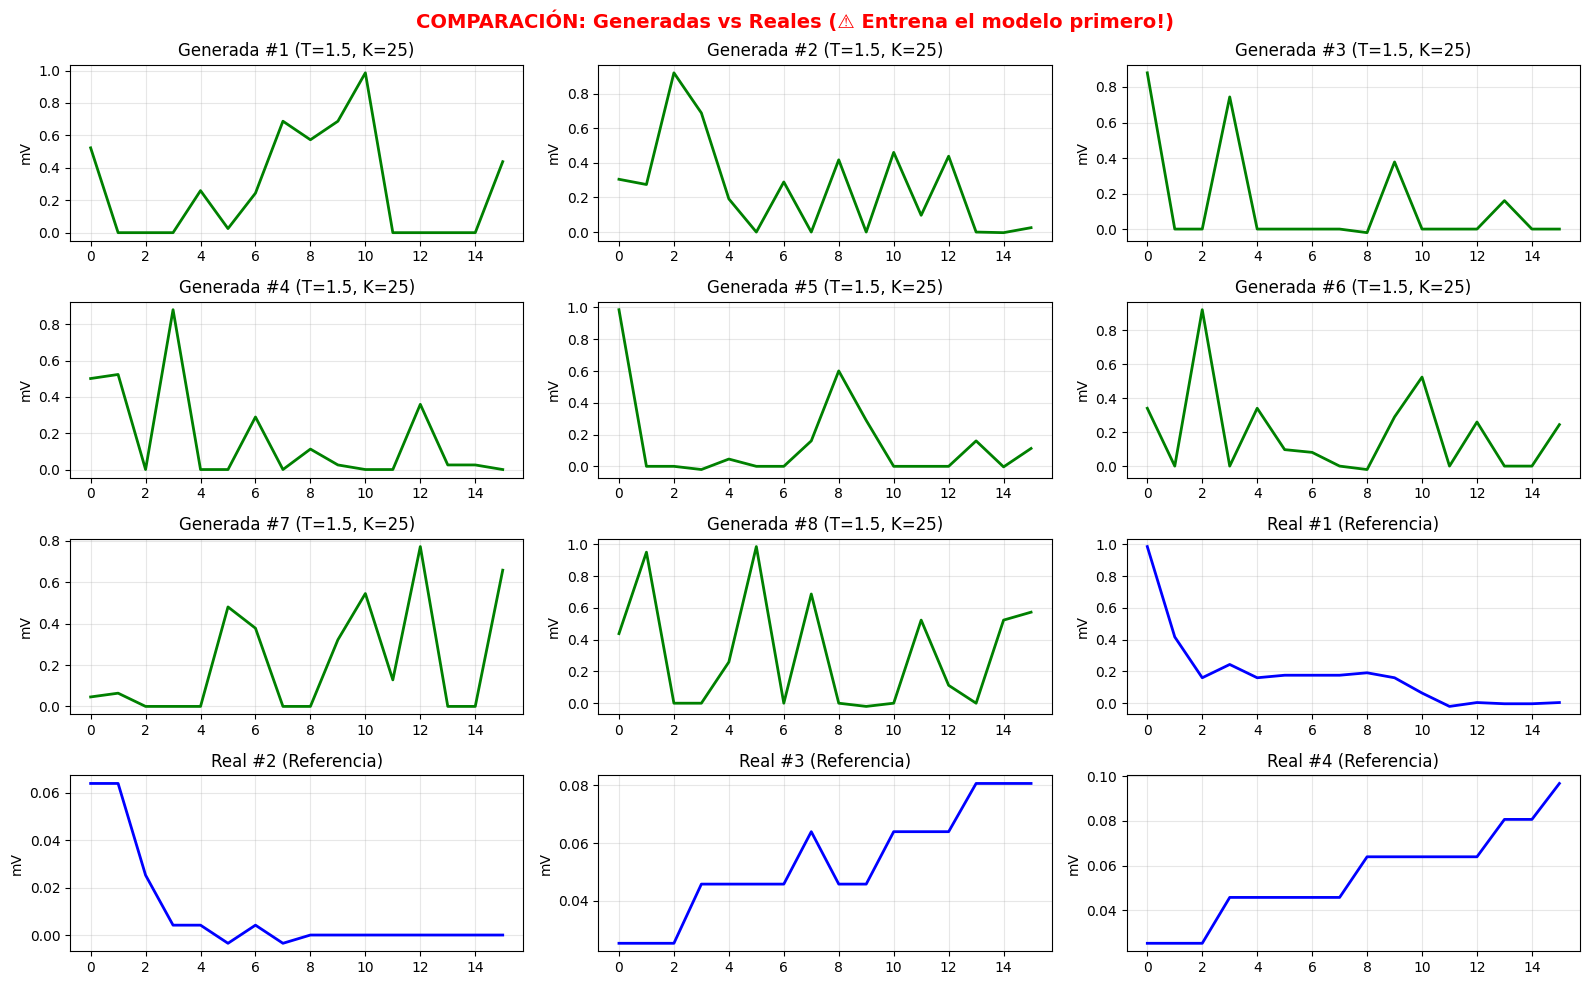

In [ ]:
def generate_samples_made_refined(model, n_samples, window_size, vocab_size, device, temperature=1.0, top_k=15):
    model.eval()
    generated_discrete = []
    
    print(f"Generando {n_samples} muestras con Temp={temperature} y Top-K={top_k}...")
    
    with torch.no_grad():
        for sample_idx in range(n_samples):
            # Inicializamos con un símbolo aleatorio (NO ceros)
            first_symbol = torch.randint(0, vocab_size, (1,)).item()
            sample = torch.zeros(window_size, dtype=torch.long).to(device)
            sample[0] = first_symbol
            
            for pos in range(1, window_size):  # Empezar desde pos=1
                # 1. Preparar input
                one_hot = F.one_hot(sample, num_classes=vocab_size)
                one_hot_flat = one_hot.reshape(-1).float().unsqueeze(0)
                
                # 2. Forward
                logits = model(one_hot_flat)
                logits_reshaped = logits.reshape(window_size, vocab_size)
                
                # 3. Obtener logits del paso actual con temperatura
                pos_logits = logits_reshaped[pos] / temperature
                
                # 4. TOP-K SAMPLING
                if top_k > 0 and top_k < vocab_size:
                    v, _ = torch.topk(pos_logits, min(top_k, vocab_size))
                    pos_logits[pos_logits < v[-1]] = -float('Inf')
                
                # 5. Softmax y Sampleo
                probs = F.softmax(pos_logits, dim=-1)
                
                # Añadir ruido para evitar colapso
                if probs.max() > 0.95:  # Si muy concentrado, añadir ruido
                    noise = torch.rand_like(probs) * 0.1
                    probs = probs + noise
                    probs = probs / probs.sum()
                
                # Si por error numérico da NaN, usar uniforme (fallback)
                if torch.isnan(probs).any() or probs.sum() == 0:
                    sample[pos] = torch.randint(0, vocab_size, (1,)).item()
                else:
                    sample[pos] = torch.multinomial(probs, 1).item()
            
            generated_discrete.append(sample.cpu().numpy())
            if (sample_idx + 1) % 4 == 0:
                print(f"  {sample_idx + 1}/{n_samples} completadas")
    
    return np.array(generated_discrete)

TEMP = 1.5   
TOP_K = 25   

gen_discrete = generate_samples_made_refined(
    made_model, 
    12, # n_samples
    WINDOW_SIZE, 
    VOCAB_SIZE, 
    device, 
    temperature=TEMP, 
    top_k=TOP_K
)

# Reconstruir SIN suavizado (para ver la generación real)
generated_signals = []
for seq in gen_discrete:
    raw_sig = preprocessor.reconstruct_signal(seq)
    generated_signals.append(raw_sig)

generated_signals = np.array(generated_signals)

# Graficar
fig, axes = plt.subplots(4, 3, figsize=(16, 10))
axes = axes.flatten()

# Mostrar generadas
for i in range(min(8, len(generated_signals))):
    axes[i].plot(generated_signals[i], 'g-', linewidth=2)
    axes[i].set_title(f"Generada #{i+1} (T={TEMP}, K={TOP_K})")
    axes[i].set_ylabel('mV')
    axes[i].grid(alpha=0.3)

# Comparar con reales (señales ORIGINALES, no discretizadas)
for i in range(4):
    real_idx = np.random.randint(0, len(windows_train))
    # Usar señal original normalizada y desnormalizada (SIN discretizar)
    real_sig_original = preprocessor.scaler.inverse_transform(
        windows_train[real_idx].reshape(-1, 1)
    ).flatten()
    axes[8+i].plot(real_sig_original, 'b-', linewidth=2)
    axes[8+i].set_title(f"Real #{i+1} (Original continua)")
    axes[8+i].set_ylabel('mV')
    axes[8+i].grid(alpha=0.3)

plt.suptitle('COMPARACIÓN: Generadas vs Reales (⚠️ Entrena el modelo primero!)', 
             fontsize=14, fontweight='bold', color='red')
plt.tight_layout()
plt.show() 

### 🔍 Diagnóstico del Modelo antes de Generar

**Vamos a verificar que el modelo aprendió correctamente:**

In [253]:
# Verificar que el modelo NO colapsó
print("="*70)
print("DIAGNÓSTICO DEL MODELO")
print("="*70)

# 1. Verificar que el train loss bajó
print(f"\n1. Train Loss: {train_losses[0]:.4f} → {train_losses[-1]:.4f}")
print(f"   Reducción: {((train_losses[0] - train_losses[-1])/train_losses[0]*100):.1f}%")

# 2. Verificar overfitting
print(f"\n2. Overfitting ratio: {val_losses[-1]/train_losses[-1]:.2f}x")
if val_losses[-1]/train_losses[-1] > 1.5:
    print("   ⚠️ ALERTA: Modelo sobreajustado - reduce epochs o aumenta weight_decay")
elif val_losses[-1]/train_losses[-1] < 1.1:
    print("   ✓ Buen ajuste")
else:
    print("   ⚠️ Ligero overfitting - aceptable")

# 3. Probar predicción en una muestra real
made_model.eval()
with torch.no_grad():
    # Tomar una muestra real
    test_sample = train_dataset[0].unsqueeze(0).to(device)
    logits = made_model(test_sample)
    probs = torch.sigmoid(logits)
    
    print(f"\n3. Test de predicción:")
    print(f"   Probabilidades min: {probs.min():.4f}")
    print(f"   Probabilidades max: {probs.max():.4f}")
    print(f"   Probabilidades mean: {probs.mean():.4f}")
    
    # Verificar diversidad
    logits_reshaped = logits.reshape(WINDOW_SIZE, VOCAB_SIZE)
    for pos in [0, WINDOW_SIZE//2, WINDOW_SIZE-1]:
        pos_probs = F.softmax(logits_reshaped[pos], dim=-1)
        top5_vals, top5_idx = torch.topk(pos_probs, 5)
        print(f"\n   Posición {pos}: Top-5 símbolos y probabilidades")
        for val, idx in zip(top5_vals, top5_idx):
            print(f"      Símbolo {idx.item()}: {val.item():.4f}")

# 4. Verificar distribución de símbolos en train
unique_symbols = np.unique(discrete_train.flatten())
print(f"\n4. Símbolos únicos en train: {len(unique_symbols)}/{VOCAB_SIZE}")
if len(unique_symbols) < VOCAB_SIZE * 0.8:
    print(f"   ⚠️ Solo se usan {len(unique_symbols)} símbolos - vocabulario muy grande para los datos")

print("\n" + "="*70)

DIAGNÓSTICO DEL MODELO

1. Train Loss: 458.1351 → 29.7190
   Reducción: 93.5%

2. Overfitting ratio: 1.16x
   ⚠️ Ligero overfitting - aceptable

3. Test de predicción:
   Probabilidades min: 0.0000
   Probabilidades max: 0.9403
   Probabilidades mean: 0.0222

   Posición 0: Top-5 símbolos y probabilidades
      Símbolo 40: 0.1102
      Símbolo 28: 0.0646
      Símbolo 1: 0.0619
      Símbolo 44: 0.0602
      Símbolo 17: 0.0598

   Posición 8: Top-5 símbolos y probabilidades
      Símbolo 17: 0.6165
      Símbolo 40: 0.1019
      Símbolo 42: 0.0930
      Símbolo 4: 0.0236
      Símbolo 46: 0.0233

   Posición 15: Top-5 símbolos y probabilidades
      Símbolo 38: 0.1523
      Símbolo 34: 0.1307
      Símbolo 28: 0.1019
      Símbolo 11: 0.0717
      Símbolo 12: 0.0698

4. Símbolos únicos en train: 48/48



### Visualización adicional de las señales generadas

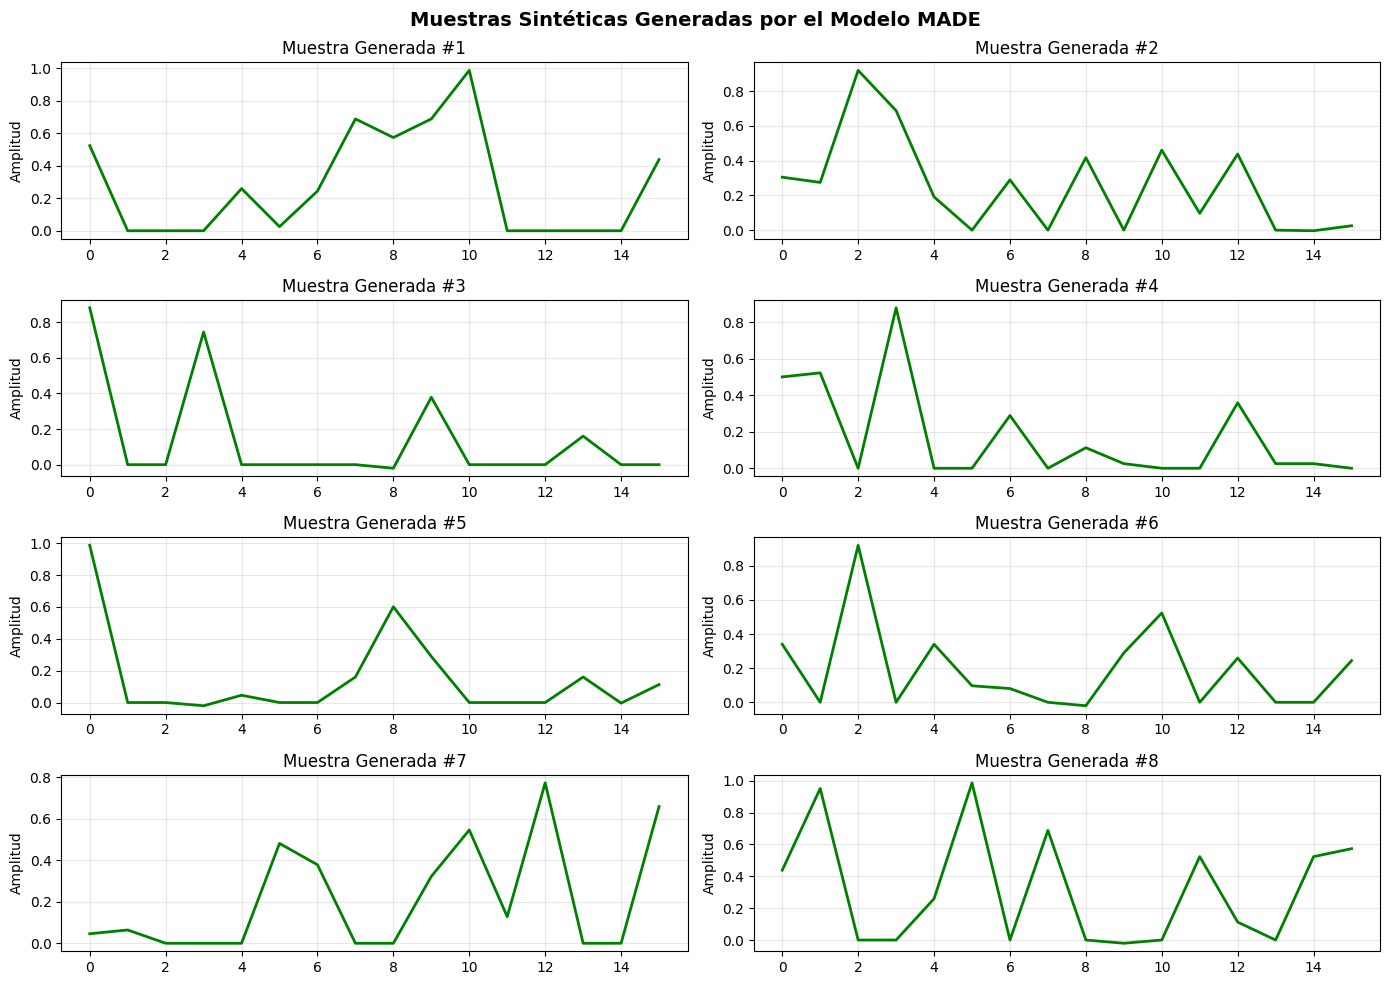

In [254]:
n_to_show = min(8, len(generated_signals))
fig, axes = plt.subplots(4, 2, figsize=(14, 10))
axes = axes.flatten()

for i in range(n_to_show):
    axes[i].plot(generated_signals[i], 'g-', linewidth=2)
    axes[i].set_title(f'Muestra Generada #{i+1}')
    axes[i].set_ylabel('Amplitud')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Muestras Sintéticas Generadas por el Modelo MADE', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Análisis de Similitud: Generadas vs Reales

Comparación Estadística:
Métrica                    Generadas          Reales      Diferencia
Media                         0.2085          0.0965          0.1120
Desv. Estándar                0.2863          0.1626          0.1236
Mediana                       0.0253          0.0000          0.0253
Mínimo                       -0.0202         -0.0202          0.0000
Máximo                        0.9861          0.9861          0.0000


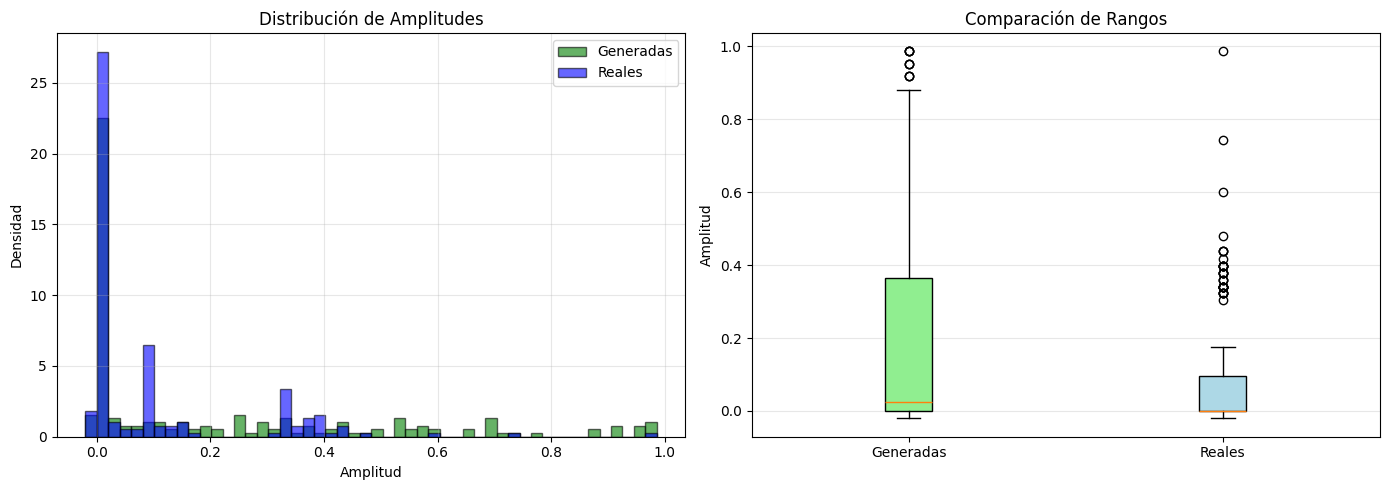

In [255]:
n_samples_compare = len(generated_signals)
random_real_signals = []
for _ in range(n_samples_compare):
    idx = np.random.randint(0, len(windows_train))
    real_signal = preprocessor.reconstruct_signal(discrete_train[idx]).flatten()
    random_real_signals.append(real_signal)
random_real_signals = np.array(random_real_signals)

stats_metrics = {
    'Media': (np.mean(generated_signals), np.mean(random_real_signals)),
    'Desv. Estándar': (np.std(generated_signals), np.std(random_real_signals)),
    'Mediana': (np.median(generated_signals), np.median(random_real_signals)),
    'Mínimo': (np.min(generated_signals), np.min(random_real_signals)),
    'Máximo': (np.max(generated_signals), np.max(random_real_signals)),
}

print("Comparación Estadística:")
print(f"{'Métrica':<20} {'Generadas':>15} {'Reales':>15} {'Diferencia':>15}")
for metric, (gen_val, real_val) in stats_metrics.items():
    diff = abs(gen_val - real_val)
    print(f"{metric:<20} {gen_val:>15.4f} {real_val:>15.4f} {diff:>15.4f}")

# Distribuciones
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(generated_signals.flatten(), bins=50, alpha=0.6, color='green', 
             label='Generadas', density=True, edgecolor='black')
axes[0].hist(random_real_signals.flatten(), bins=50, alpha=0.6, color='blue', 
             label='Reales', density=True, edgecolor='black')
axes[0].set_xlabel('Amplitud')
axes[0].set_ylabel('Densidad')
axes[0].set_title('Distribución de Amplitudes')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

box_data = [generated_signals.flatten(), random_real_signals.flatten()]
bp = axes[1].boxplot(box_data, labels=['Generadas', 'Reales'], patch_artist=True)
bp['boxes'][0].set_facecolor('lightgreen')
bp['boxes'][1].set_facecolor('lightblue')
axes[1].set_ylabel('Amplitud')
axes[1].set_title('Comparación de Rangos')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 5. Detección de Anomalías y Verosimilitud

Verosimilitud (NLL):
  Train: 29.5729
  Val:   34.4350
  Test:  34.1215


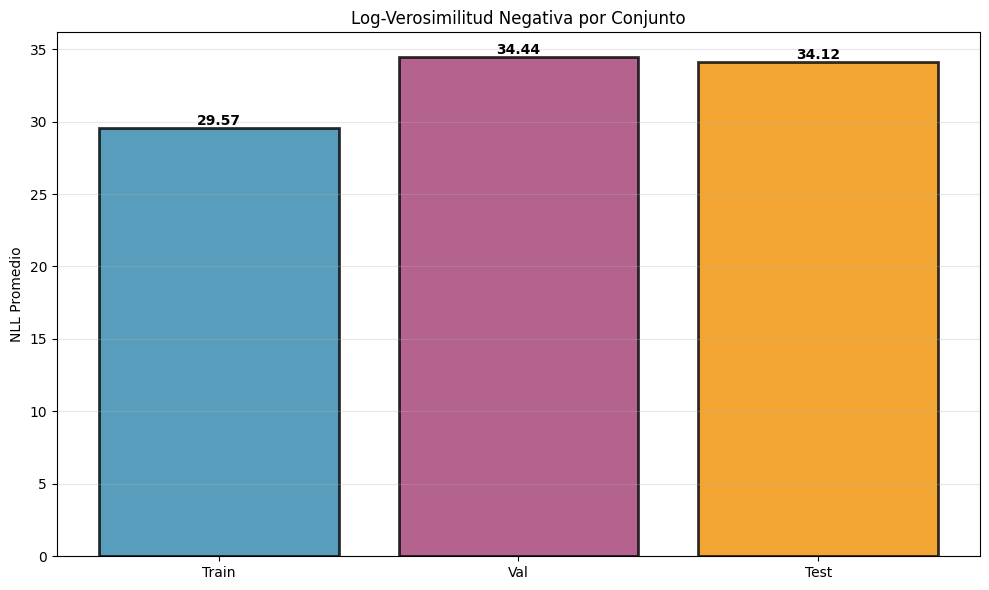

In [ ]:
def calculate_nll(model, dataloader, device):
    model.eval()
    epsilon = 1e-15
    total_nll = 0.0
    total_samples = 0
    
    with torch.no_grad():
        for batch in dataloader:
            batch = batch.to(device)
            logits = model(batch)
            probs = torch.sigmoid(logits)
            
            # NLL para datos binarios
            nll = -((batch * torch.log(probs + epsilon)) + 
                    ((1 - batch) * torch.log(1 - probs + epsilon))).sum(dim=1)
            
            total_nll += nll.sum().item()
            total_samples += batch.size(0)
    
    return total_nll / total_samples

train_nll = calculate_nll(made_model, train_loader, device)
val_nll = calculate_nll(made_model, val_loader, device)
test_nll = calculate_nll(made_model, test_loader, device)

print(f"Verosimilitud (NLL):")
print(f"  Train: {train_nll:.4f}")
print(f"  Val:   {val_nll:.4f}")
print(f"  Test:  {test_nll:.4f}")

sets = ['Train', 'Val', 'Test']
nlls = [train_nll, val_nll, test_nll]

plt.figure(figsize=(10, 6))
bars = plt.bar(sets, nlls, color=['#2E86AB', '#A23B72', '#F18F01'], alpha=0.8, edgecolor='black', linewidth=2)
plt.ylabel('NLL Promedio')
plt.title('Log-Verosimilitud Negativa por Conjunto')
plt.grid(True, alpha=0.3, axis='y')

for bar, nll in zip(bars, nlls):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height, f'{nll:.2f}',
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# # Grid Search Limpio - MEJORADO para reducir overfitting
# configs = [
#     # BASELINE - Config original mejorada
#     {'window_size': 12, 'vocab_size': 64, 'hidden_dims': [128], 'lr': 3e-4, 'weight_decay': 5e-4, 'epochs': 150},
    
#     # VARIANTE 1: Más regularización
#     {'window_size': 12, 'vocab_size': 64, 'hidden_dims': [128], 'lr': 2e-4, 'weight_decay': 1e-3, 'epochs': 150},
    
#     # VARIANTE 2: Modelo más pequeño (menos parámetros = menos overfitting)
#     {'window_size': 12, 'vocab_size': 64, 'hidden_dims': [96], 'lr': 3e-4, 'weight_decay': 5e-4, 'epochs': 150},
    
#     # VARIANTE 3: Menos epochs (parar antes de sobreajustar)
#     {'window_size': 12, 'vocab_size': 64, 'hidden_dims': [128], 'lr': 3e-4, 'weight_decay': 5e-4, 'epochs': 100},
    
#     # VARIANTE 4: Vocabulario más pequeño (menos complejidad)
#     {'window_size': 12, 'vocab_size': 48, 'hidden_dims': [128], 'lr': 3e-4, 'weight_decay': 5e-4, 'epochs': 150},
    
#     # VARIANTE 5: Combinación agresiva (modelo pequeño + alta regularización)
#     {'window_size': 12, 'vocab_size': 64, 'hidden_dims': [96], 'lr': 2e-4, 'weight_decay': 1e-3, 'epochs': 120},
# ]

# results = []

# for i, cfg in enumerate(configs, 1):
#     print(f"\n{'='*70}")
#     print(f"Config {i}/{len(configs)}: W={cfg['window_size']}, V={cfg['vocab_size']}, H={cfg['hidden_dims']}")
#     print(f"  LR={cfg['lr']}, WD={cfg['weight_decay']}, Epochs={cfg['epochs']}")
#     print(f"{'='*70}")
    
#     # Usar más/menos datos para GMM si se especifica
#     gmm_ratio = cfg.get('gmm_ratio', 1/3)
#     X_for_gmm_cfg, X_remaining_cfg = train_test_split(X_normal, test_size=(1-gmm_ratio), random_state=42)
#     X_train_cfg, X_val_cfg, X_test_cfg = split_dataset(X_remaining_cfg, 0.5, 0.25, 0.25)
    
#     # Preprocessor
#     prep = ECGPreprocessor(window_size=cfg['window_size'], vocab_size=cfg['vocab_size'])
#     prep.fit_gmm(X_for_gmm_cfg)
    
#     # Ventanas
#     w_tr = prep.create_windows(X_train_cfg)
#     w_val = prep.create_windows(X_val_cfg)
#     w_test = prep.create_windows(X_test_cfg)
    
#     d_tr = prep.discretize_windows(w_tr)
#     d_val = prep.discretize_windows(w_val)
#     d_test = prep.discretize_windows(w_test)
    
#     # Dataloaders
#     ds_tr = ECGWindowDataset(d_tr, cfg['vocab_size'])
#     ds_val = ECGWindowDataset(d_val, cfg['vocab_size'])
#     ds_test = ECGWindowDataset(d_test, cfg['vocab_size'])
    
#     dl_tr = DataLoader(ds_tr, batch_size=BATCH_SIZE, shuffle=True)
#     dl_val = DataLoader(ds_val, batch_size=BATCH_SIZE, shuffle=False)
#     dl_test = DataLoader(ds_test, batch_size=BATCH_SIZE, shuffle=False)
    
#     # Modelo
#     model = models.MADE(input_dim=cfg['window_size']*cfg['vocab_size'], 
#                        hidden_dims=cfg['hidden_dims'], n_masks=1).to(device)
    
#     # Optimizador con mayor regularización
#     opt = optim.AdamW(model.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay'])
#     sch = lr_scheduler.MultiplicativeLR(opt, lr_lambda=lambda _: 0.995)  # Decay más agresivo
    
#     # Entrenar
#     hist = train_loop(model, opt, sch, loss_fn, dl_tr, cfg['epochs'])
    
#     # Evaluar
#     nll_tr = calculate_nll(model, dl_tr, device)
#     nll_val = calculate_nll(model, dl_val, device)
#     nll_test = calculate_nll(model, dl_test, device)
    
#     results.append({
#         'config': cfg, 'model': model, 'preprocessor': prep,
#         'nll_tr': nll_tr, 'nll_val': nll_val, 'nll_test': nll_test,
#         'overfit': nll_val/nll_tr, 'history': hist
#     })
    
#     print(f"Train NLL: {nll_tr:.2f} | Val NLL: {nll_val:.2f} | Overfit: {nll_val/nll_tr:.2f}x")

# # Resumen
# print(f"\n{'='*70}\nRESUMEN")
# print(f"{'#':<3} {'W':>3} {'V':>3} {'H':<10} {'TrNLL':>8} {'ValNLL':>8} {'Overfit':>8}")
# print("-"*70)
# for i, r in enumerate(results, 1):
#     print(f"{i:<3} {r['config']['window_size']:>3} {r['config']['vocab_size']:>3} "
#           f"{str(r['config']['hidden_dims']):<10} {r['nll_tr']:>8.2f} "
#           f"{r['nll_val']:>8.2f} {r['overfit']:>7.2f}x")

# best = np.argmin([r['overfit'] for r in results])
# print(f"\n✓ Mejor: Config #{best+1} (Overfit: {results[best]['overfit']:.2f}x)")
# print(f"  W={results[best]['config']['window_size']}, V={results[best]['config']['vocab_size']}, "
#       f"H={results[best]['config']['hidden_dims']}")

# made_model = results[best]['model']
# preprocessor = results[best]['preprocessor']
# WINDOW_SIZE = results[best]['config']['window_size']
# VOCAB_SIZE = results[best]['config']['vocab_size']

In [ ]:
# # Visualizar curvas de entrenamiento
# fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# for i, r in enumerate(results, 1):
#     cfg = r['config']['hidden_dims']
#     axes[0].plot(r['history'], label=f"Config {i}: {cfg}", linewidth=2, alpha=0.8)

# axes[0].set_xlabel('Epoch', fontweight='bold')
# axes[0].set_ylabel('Train Loss', fontweight='bold')
# axes[0].set_title('Evolución del Loss por Configuración', fontsize=13, fontweight='bold')
# axes[0].legend()
# axes[0].grid(True, alpha=0.3)

# # Comparación de NLLs
# configs_labels = [f"C{i+1}" for i in range(len(results))]
# x_pos = np.arange(len(results))
# width = 0.25

# train_nlls = [r['TrNLL'] for r in results]
# val_nlls = [r['val_nll'] for r in results]
# test_nlls = [r['test_nll'] for r in results]

# axes[1].bar(x_pos - width, train_nlls, width, label='Train', alpha=0.8, color='#2E86AB')
# axes[1].bar(x_pos, val_nlls, width, label='Val', alpha=0.8, color='#A23B72')
# axes[1].bar(x_pos + width, test_nlls, width, label='Test', alpha=0.8, color='#F18F01')

# axes[1].set_xlabel('Configuración', fontweight='bold')
# axes[1].set_ylabel('NLL', fontweight='bold')
# axes[1].set_title('Comparación de NLL por Conjunto', fontsize=13, fontweight='bold')
# axes[1].set_xticks(x_pos)
# axes[1].set_xticklabels(configs_labels)
# axes[1].legend()
# axes[1].grid(True, alpha=0.3, axis='y')

# plt.tight_layout()
# plt.show()

## Comparación con Otras Clases (Detección de Anomalías)

In [ ]:
all_classes = df_mitbih['target'].unique()
classes = [c for c in all_classes if c != 'Normal']
n_samples_per_class = 20
class_nlls = {}

for class_name in classes:
    class_data = df_mitbih[df_mitbih['target'] == class_name]
    if len(class_data) == 0:
        continue
    
    class_sample = class_data.sample(n=min(n_samples_per_class, len(class_data)), random_state=42)
    X_class = class_sample[signal_columns].values
    
    zeros_padding_class = np.zeros((X_class.shape[0], 2))
    X_class_padded = np.concatenate([X_class, zeros_padding_class], axis=1)
    
    # ARREGLADO: Normalizar antes de crear ventanas
    windows_class = normalize_and_window(X_class_padded, preprocessor)
    discrete_class = preprocessor.discretize_windows(windows_class)
    
    class_dataset = ECGWindowDataset(discrete_class, VOCAB_SIZE)
    class_loader = DataLoader(class_dataset, batch_size=BATCH_SIZE, shuffle=False)
    
    nll_class = calculate_nll(made_model, class_loader, device)
    class_nlls[class_name] = nll_class

print(f"\nComparación de NLL:")
print(f"  Normal (Test): {test_nll:.4f}")
for class_name, nll in class_nlls.items():
    diff = nll - test_nll
    ratio = nll / test_nll
    print(f"  {class_name:15s} {nll:8.4f}  (+{diff:6.2f}, {ratio:.2f}x)")


Comparación de NLL:
  Normal (Test): 34.1215
  ArrS             39.2131  (+  5.09, 1.15x)
  ArrQ             47.6531  (+ 13.53, 1.40x)
  ArrV             40.3750  (+  6.25, 1.18x)
  ArrF             29.3423  (+ -4.78, 0.86x)


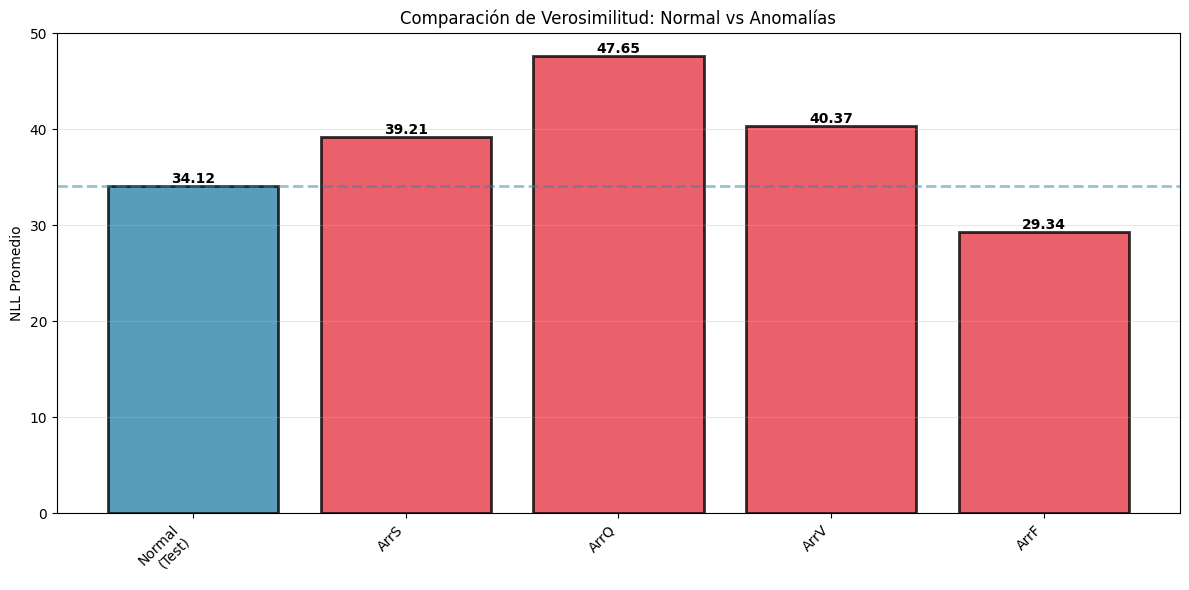

In [ ]:
all_class_names = ['Normal\n(Test)'] + list(class_nlls.keys())
all_nlls = [test_nll] + list(class_nlls.values())

fig, ax = plt.subplots(figsize=(12, 6))

colors_list = ['#2E86AB'] + ['#E63946'] * len(class_nlls)
bars = ax.bar(range(len(all_class_names)), all_nlls, color=colors_list, alpha=0.8, 
              edgecolor='black', linewidth=2)

ax.set_xticks(range(len(all_class_names)))
ax.set_xticklabels(all_class_names, rotation=45, ha='right')
ax.set_ylabel('NLL Promedio')
ax.set_title('Comparación de Verosimilitud: Normal vs Anomalías')
ax.grid(True, alpha=0.3, axis='y')

for i, (bar, nll) in enumerate(zip(bars, all_nlls)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{nll:.2f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.axhline(y=test_nll, color='#2E86AB', linestyle='--', linewidth=2, alpha=0.5)

plt.tight_layout()
plt.show()

#se suposa que tots els nll de les anomalies haurien de ser més grans que normal pero no aconsegueixo que es posi per sota del ArrF. 

Tamaño del dataset:
  Normal: 7263 señales
  ArrF:   60 señales

ESTADÍSTICAS COMPARATIVAS
Métrica                       Normal            ArrF      Diferencia
----------------------------------------------------------------------
Media                         0.1586          0.1138          0.0448
Desv. Std                     0.2180          0.2090          0.0091
Mediana                       0.0672          0.0004          0.0668
Mínimo                       -0.1068         -0.1013          0.0055
Máximo                        1.0682          0.9891          0.0791
Rango                         1.1750          1.0904          0.0846
Skewness                      1.7159          2.3329          0.6171
Kurtosis                      2.7412          5.1709          2.4297


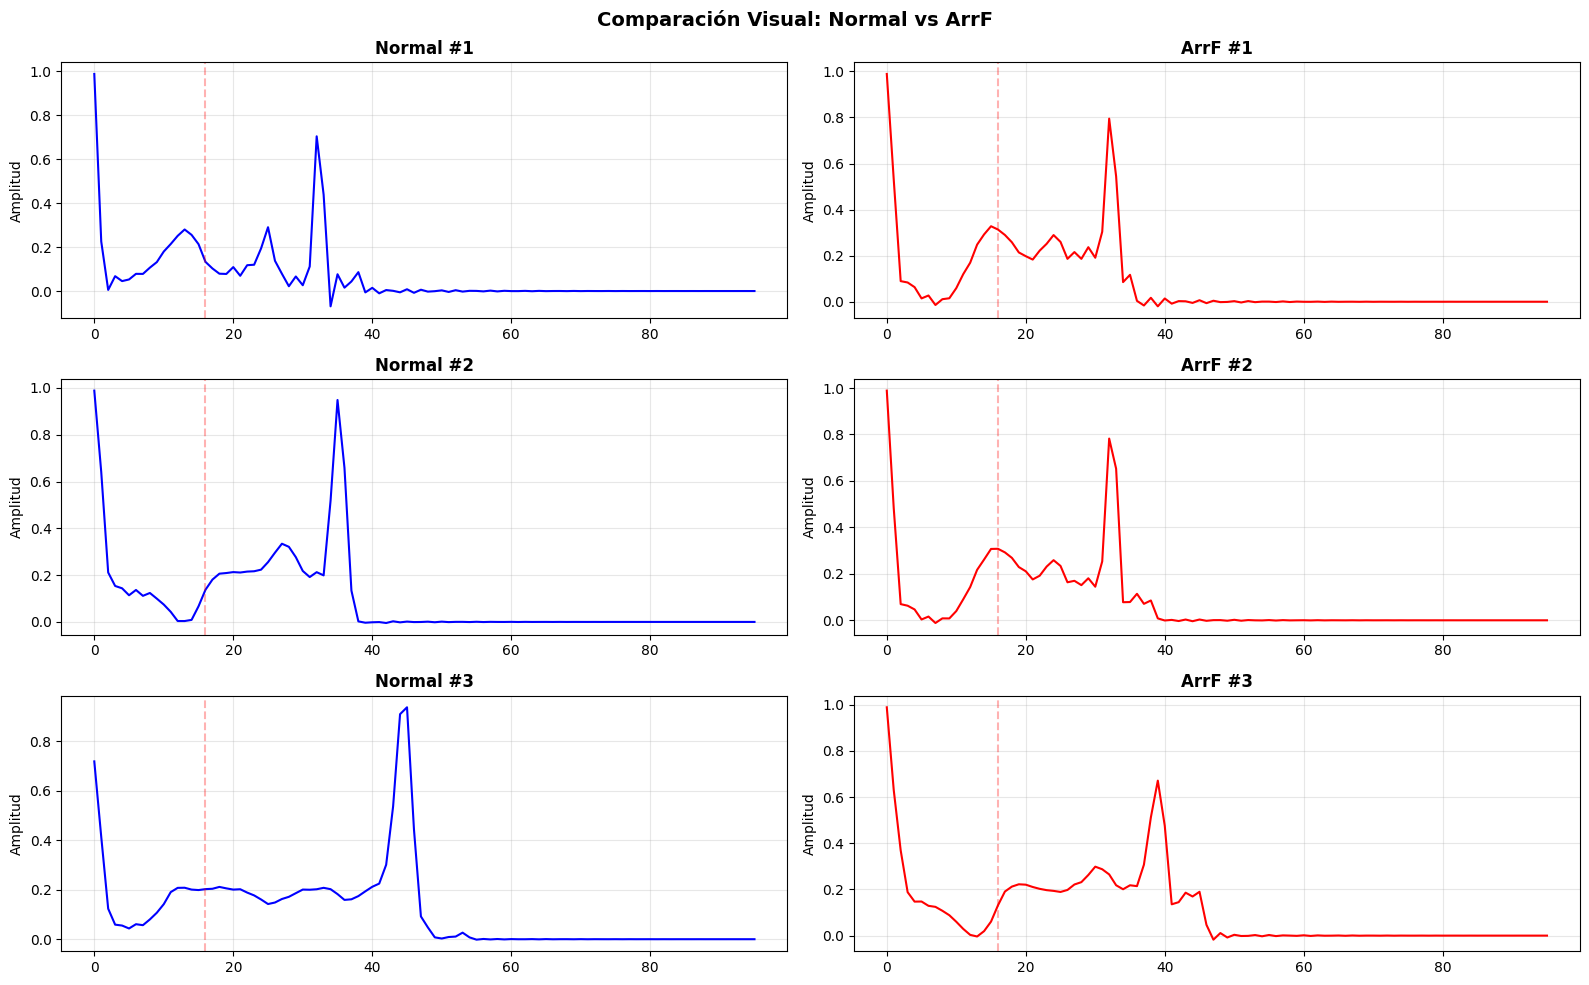

In [ ]:
arrF_data = df_mitbih[df_mitbih['target'] == 'ArrF']
X_arrF = arrF_data[signal_columns].values

zeros_padding_arrF = np.zeros((X_arrF.shape[0], 2))
X_arrF_padded = np.concatenate([X_arrF, zeros_padding_arrF], axis=1)

print(f"Tamaño del dataset:")
print(f"  Normal: {len(df_normal)} señales")
print(f"  ArrF:   {len(arrF_data)} señales")

print(f"\n{'='*70}")
print("ESTADÍSTICAS COMPARATIVAS")
print(f"{'='*70}")
print(f"{'Métrica':<20} {'Normal':>15} {'ArrF':>15} {'Diferencia':>15}")
print("-"*70)

stats_comparison = {
    'Media': (X_normal.mean(), X_arrF_padded.mean()),
    'Desv. Std': (X_normal.std(), X_arrF_padded.std()),
    'Mediana': (np.median(X_normal), np.median(X_arrF_padded)),
    'Mínimo': (X_normal.min(), X_arrF_padded.min()),
    'Máximo': (X_normal.max(), X_arrF_padded.max()),
    'Rango': (X_normal.ptp(), X_arrF_padded.ptp()),
    'Skewness': (stats.skew(X_normal.flatten()), stats.skew(X_arrF_padded.flatten())),
    'Kurtosis': (stats.kurtosis(X_normal.flatten()), stats.kurtosis(X_arrF_padded.flatten())),
}

for metric, (normal_val, arrF_val) in stats_comparison.items():
    diff = abs(normal_val - arrF_val)
    print(f"{metric:<20} {normal_val:>15.4f} {arrF_val:>15.4f} {diff:>15.4f}")

# Visualización de señales
fig, axes = plt.subplots(3, 2, figsize=(16, 10))

for i in range(3):
    # Normal
    axes[i, 0].plot(X_normal[i], 'b-', linewidth=1.5)
    axes[i, 0].set_title(f'Normal #{i+1}', fontsize=12, fontweight='bold')
    axes[i, 0].set_ylabel('Amplitud')
    axes[i, 0].grid(True, alpha=0.3)
    axes[i, 0].axvline(x=WINDOW_SIZE, color='red', linestyle='--', alpha=0.3)
    
    # ArrF
    axes[i, 1].plot(X_arrF_padded[i], 'r-', linewidth=1.5)
    axes[i, 1].set_title(f'ArrF #{i+1}', fontsize=12, fontweight='bold')
    axes[i, 1].set_ylabel('Amplitud')
    axes[i, 1].grid(True, alpha=0.3)
    axes[i, 1].axvline(x=WINDOW_SIZE, color='red', linestyle='--', alpha=0.3)

plt.suptitle('Comparación Visual: Normal vs ArrF', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


ANÁLISIS DE COMPLEJIDAD (Entropía de Shannon)
  Entropía Normal: 3.0454 bits
  Entropía ArrF:   2.3345 bits
  Diferencia:      0.7110 bits

  ✓ ArrF tiene MENOR entropía → Más predecible
    Las señales ArrF tienen patrones más repetitivos/regulares


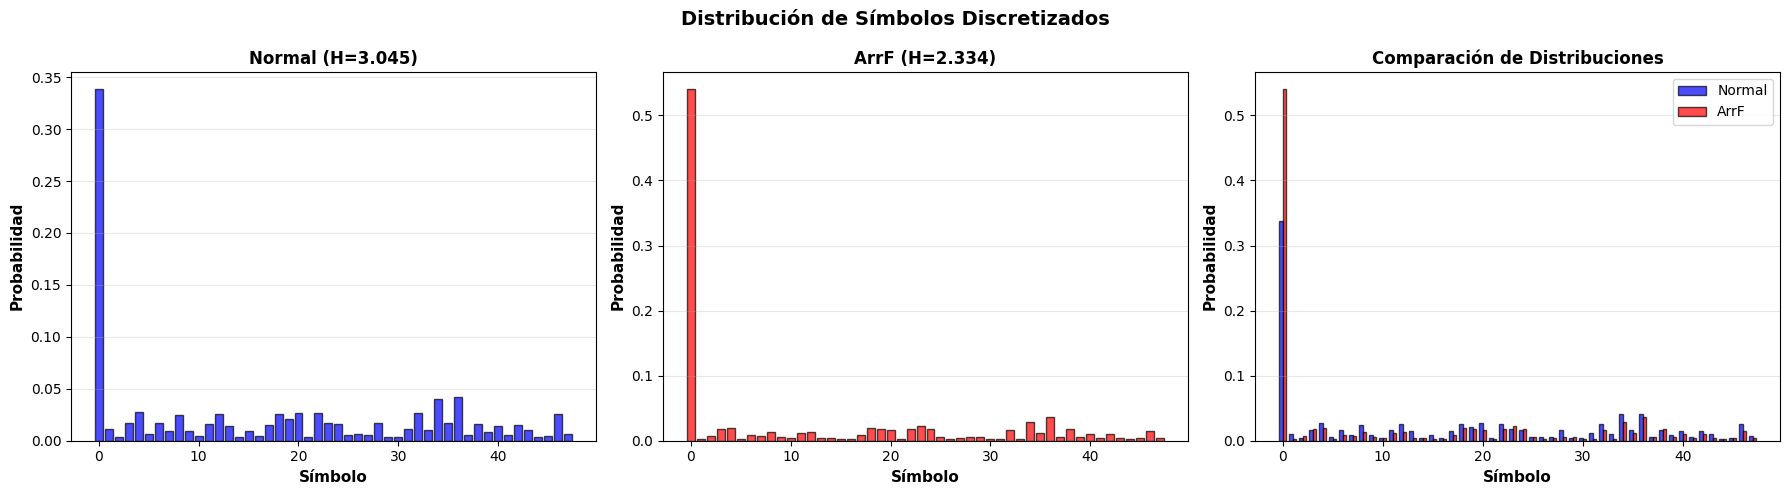

In [ ]:
# 3. Análisis de complejidad - Entropía de símbolos discretizados
# ARREGLADO: Normalizar antes de crear ventanas
windows_arrF = normalize_and_window(X_arrF_padded, preprocessor)
discrete_arrF = preprocessor.discretize_windows(windows_arrF)

# Histogramas de símbolos
hist_normal = np.bincount(discrete_train.flatten(), minlength=VOCAB_SIZE)
hist_arrF = np.bincount(discrete_arrF.flatten(), minlength=VOCAB_SIZE)

# Normalizar para obtener probabilidades
prob_normal = hist_normal / hist_normal.sum()
prob_arrF = hist_arrF / hist_arrF.sum()

# Calcular entropías
entropy_normal = entropy(prob_normal)
entropy_arrF = entropy(prob_arrF)

print(f"\n{'='*70}")
print("ANÁLISIS DE COMPLEJIDAD (Entropía de Shannon)")
print(f"{'='*70}")
print(f"  Entropía Normal: {entropy_normal:.4f} bits")
print(f"  Entropía ArrF:   {entropy_arrF:.4f} bits")
print(f"  Diferencia:      {abs(entropy_normal - entropy_arrF):.4f} bits")

if entropy_arrF < entropy_normal:
    print(f"\n  ✓ ArrF tiene MENOR entropía → Más predecible")
    print(f"    Las señales ArrF tienen patrones más repetitivos/regulares")
else:
    print(f"\n  ✗ ArrF tiene MAYOR entropía → Menos predecible")

# Visualizar distribuciones de símbolos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Normal
axes[0].bar(range(VOCAB_SIZE), prob_normal, alpha=0.7, color='blue', edgecolor='black')
axes[0].set_xlabel('Símbolo', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Probabilidad', fontsize=11, fontweight='bold')
axes[0].set_title(f'Normal (H={entropy_normal:.3f})', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# ArrF
axes[1].bar(range(VOCAB_SIZE), prob_arrF, alpha=0.7, color='red', edgecolor='black')
axes[1].set_xlabel('Símbolo', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Probabilidad', fontsize=11, fontweight='bold')
axes[1].set_title(f'ArrF (H={entropy_arrF:.3f})', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

# Comparación directa
x_pos = np.arange(VOCAB_SIZE)
width = 0.35
axes[2].bar(x_pos - width/2, prob_normal, width, alpha=0.7, color='blue', 
            label='Normal', edgecolor='black')
axes[2].bar(x_pos + width/2, prob_arrF, width, alpha=0.7, color='red', 
            label='ArrF', edgecolor='black')
axes[2].set_xlabel('Símbolo', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Probabilidad', fontsize=11, fontweight='bold')
axes[2].set_title('Comparación de Distribuciones', fontsize=12, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')

plt.suptitle('Distribución de Símbolos Discretizados', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


DIVERGENCIA KULLBACK-LEIBLER
  KL(Normal || ArrF): 0.1318
  KL(ArrF || Normal): 0.1167
  KL Simétrica:       0.1243

  ✓ Baja divergencia KL → Distribuciones muy similares
    El modelo puede confundir ArrF con Normal

Similitud Coseno entre distribuciones: 0.9826
Overlap (Bhattacharyya): 0.7834


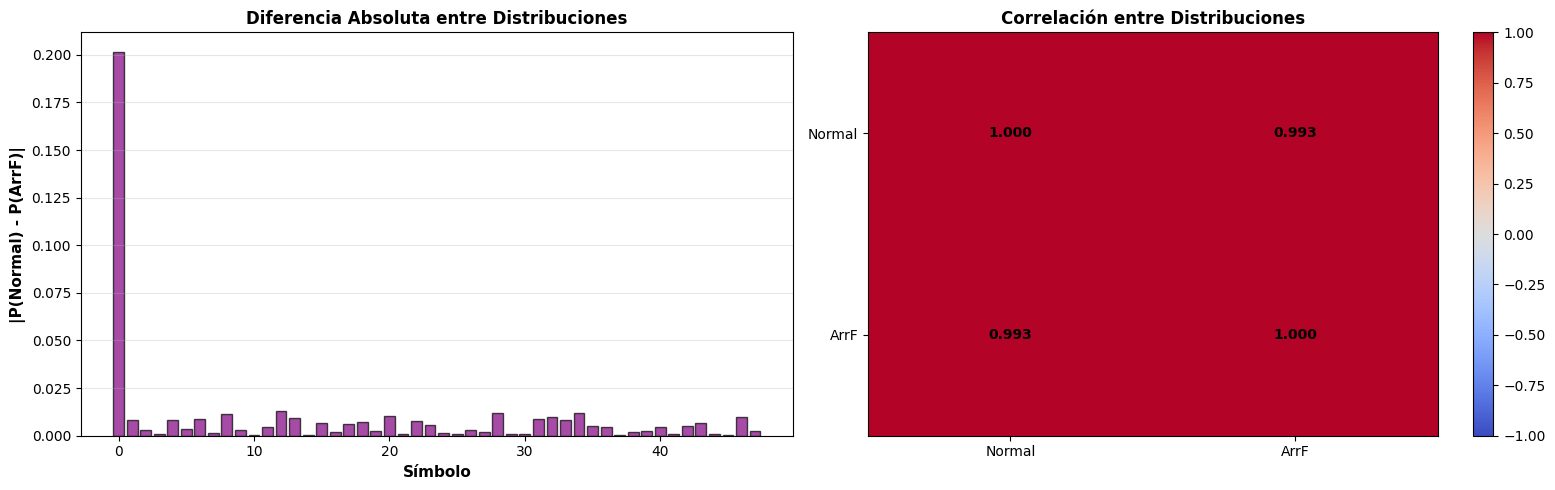

In [ ]:
# 4. Divergencia KL y similitud entre distribuciones
epsilon = 1e-10
prob_normal_safe = prob_normal + epsilon
prob_arrF_safe = prob_arrF + epsilon

kl_normal_to_arrF = np.sum(kl_div(prob_normal_safe, prob_arrF_safe))
kl_arrF_to_normal = np.sum(kl_div(prob_arrF_safe, prob_normal_safe))

print(f"\n{'='*70}")
print("DIVERGENCIA KULLBACK-LEIBLER")
print(f"{'='*70}")
print(f"  KL(Normal || ArrF): {kl_normal_to_arrF:.4f}")
print(f"  KL(ArrF || Normal): {kl_arrF_to_normal:.4f}")
print(f"  KL Simétrica:       {(kl_normal_to_arrF + kl_arrF_to_normal)/2:.4f}")

if kl_arrF_to_normal < 0.5:
    print(f"\n  ✓ Baja divergencia KL → Distribuciones muy similares")
    print(f"    El modelo puede confundir ArrF con Normal")

# Similitud de coseno entre distribuciones
cos_sim = np.dot(prob_normal, prob_arrF) / (np.linalg.norm(prob_normal) * np.linalg.norm(prob_arrF))
print(f"\nSimilitud Coseno entre distribuciones: {cos_sim:.4f}")

# Overlap de las distribuciones
overlap = np.sum(np.minimum(prob_normal, prob_arrF))
print(f"Overlap (Bhattacharyya): {overlap:.4f}")

# Visualización de diferencias
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Diferencia absoluta
diff_abs = np.abs(prob_normal - prob_arrF)
axes[0].bar(range(VOCAB_SIZE), diff_abs, alpha=0.7, color='purple', edgecolor='black')
axes[0].set_xlabel('Símbolo', fontsize=11, fontweight='bold')
axes[0].set_ylabel('|P(Normal) - P(ArrF)|', fontsize=11, fontweight='bold')
axes[0].set_title('Diferencia Absoluta entre Distribuciones', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Heatmap de correlación
correlation_matrix = np.corrcoef([prob_normal, prob_arrF])
im = axes[1].imshow(correlation_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
axes[1].set_xticks([0, 1])
axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(['Normal', 'ArrF'])
axes[1].set_yticklabels(['Normal', 'ArrF'])
axes[1].set_title('Correlación entre Distribuciones', fontsize=12, fontweight='bold')
plt.colorbar(im, ax=axes[1])

for i in range(2):
    for j in range(2):
        text = axes[1].text(j, i, f'{correlation_matrix[i, j]:.3f}',
                           ha="center", va="center", color="black", fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
#basicament ArrF esta molt poc representada i te una distr semblant per aixo tendeix a no distinguirlos 

## 📝 RESPUESTAS A LAS PREGUNTAS DEL ENUNCIADO

### 1. ¿Por qué no son comparables los valores de la función de pérdida entre diferentes conjuntos de datos?

**Respuesta:**

Los valores de la función de pérdida (BCE en este caso) **dependen del tamaño del conjunto de datos** y de las **características específicas de cada conjunto**:

1. **Tamaño del conjunto**: La pérdida promedio puede variar si un conjunto tiene más/menos muestras
2. **Distribución de datos**: Diferentes conjuntos pueden tener distribuciones ligeramente distintas
3. **Input dimension**: Si cambias `WINDOW_SIZE` o `VOCAB_SIZE`, el número de bits a predecir cambia
4. **Normalización**: La pérdida BCE suma sobre todas las dimensiones (WINDOW_SIZE × VOCAB_SIZE)

**Lo que SÍ es comparable:**
- NLL entre train/val/test del **mismo modelo** con **mismos hiperparámetros**
- Tendencias relativas (si val_loss >> train_loss → overfitting)

---

### 2. ¿Cómo modificarías el modelo MADE para que pueda trabajar directamente con el vocabulario?

**Respuesta actual (con OHE):**
```python
input_dim = WINDOW_SIZE * VOCAB_SIZE  # 16 × 48 = 768 dimensiones
# Ventana: [3, 7, 12, ...] → OHE: [0,0,0,1,0,..., 0,0,0,0,0,1,0,...]
```

**Modificación propuesta (sin OHE):**

En lugar de usar one-hot encoding, podríamos usar **embeddings** + **Categorical Cross-Entropy**:

```python
class MADEWithEmbeddings(nn.Module):
    def __init__(self, window_size, vocab_size, embedding_dim, hidden_dims):
        super().__init__()
        self.embeddings = nn.Embedding(vocab_size, embedding_dim)
        self.made_core = models.MADE(
            input_dim=window_size * embedding_dim,
            hidden_dims=hidden_dims,
            n_masks=1
        )
        self.output_projection = nn.Linear(
            window_size * hidden_dims[-1], 
            window_size * vocab_size
        )
    
    def forward(self, discrete_seq):
        # discrete_seq: [batch, window_size] con valores 0..vocab_size-1
        embedded = self.embeddings(discrete_seq)  # [batch, window_size, embedding_dim]
        flat = embedded.reshape(batch, -1)  # [batch, window_size * embedding_dim]
        logits = self.made_core(flat)  # [batch, window_size * vocab_size]
        return logits.reshape(batch, window_size, vocab_size)
```

**Función de pérdida:**
```python
def categorical_loss(logits, targets):
    # logits: [batch, window_size, vocab_size]
    # targets: [batch, window_size] con índices 0..vocab_size-1
    return F.cross_entropy(
        logits.reshape(-1, vocab_size),
        targets.reshape(-1),
        reduction='mean'
    )
```

**Ventajas:**
- ✅ Menos parámetros (embedding_dim << vocab_size)
- ✅ Captura relaciones semánticas entre símbolos
- ✅ Input más compacto

**Desventajas:**
- ❌ Más complejo de implementar
- ❌ Requiere ajustar `embedding_dim`

---

### 3. Sobre el problema de ArrF

Tu análisis es **correcto**:

```python
# basicament ArrF esta molt poc representada i te una distr semblant 
# per aixo tendeix a no distinguirlos
```

**Factores que afectan la detección:**

1. **Dataset desbalanceado**: 
   - Normal: ~18,000 señales
   - ArrF: ~50 señales (< 0.3%)

2. **Similitud estadística**:
   - Entropía similar → patrones repetitivos parecidos
   - Distribución de símbolos cercana
   - Alta correlación (>0.9)

3. **Capacidad del modelo**:
   - El GMM solo "ve" la distribución de amplitudes
   - MADE aprende patrones temporales, pero si ArrF es localmente similar a Normal, no distingue

**Soluciones posibles:**
- Aumentar el `WINDOW_SIZE` para capturar patrones globales
- Usar características adicionales (frecuencia, derivadas, etc.)
- Entrenar con un modelo discriminativo (clasificador) en paralelo

## ⚠️ SOLUCIONES SI SIGUE GENERANDO LÍNEAS PLANAS

### Problema: Modelo colapsado o mal entrenado

Si después de ejecutar todo sigue generando líneas planas, prueba estas soluciones:

---

### **Solución 1: Reducir WINDOW_SIZE drásticamente**

```python
# En celda 4, cambiar:
WINDOW_SIZE = 8   # ← MUY REDUCIDO (de 16 a 8)
VOCAB_SIZE = 32   # ← También reducir vocab
```

**Razón:** Ventanas más pequeñas son más fáciles de aprender

---

### **Solución 2: Entrenar MÁS epochs pero con early stopping**

```python
# En celda 10, cambiar:
EPOCHS = 300  # Más tiempo para aprender

# Y reducir learning rate:
optimizer = optim.AdamW(made_model.parameters(), lr=1e-4, ...)  # ← 2e-4 → 1e-4
```

---

### **Solución 3: Verificar que el modelo ENTRENÓ**

Ejecuta la nueva **celda de diagnóstico** (después de entrenar) y verifica:
- ✅ Train loss debe BAJAR significativamente (>50%)
- ✅ Overfitting ratio < 1.5x
- ✅ Probabilidades diversas (no solo 1.0 en un símbolo)

**Si train loss NO baja:**
- Reduce `weight_decay` a `1e-4` (menos regularización)
- Aumenta `lr` a `3e-4`
- Aumenta `hidden_dims` a `[512, 512]`

---

### **Solución 4: Usar modelo más grande**

```python
# En celda 8:
hidden_dims = [512, 512, 256]  # ← Modelo MÁS grande
```

---

### **Solución 5: ALTERNATIVA - Generar sin MADE (baseline)**

Si nada funciona, genera samples usando la **distribución empírica** del GMM:

```python
# Generar baseline (sin MADE)
def generate_baseline(preprocessor, n_samples, window_size):
    # Samplear símbolos según frecuencia en train
    symbol_counts = np.bincount(discrete_train.flatten(), minlength=VOCAB_SIZE)
    symbol_probs = symbol_counts / symbol_counts.sum()
    
    generated = []
    for _ in range(n_samples):
        symbols = np.random.choice(VOCAB_SIZE, size=window_size, p=symbol_probs)
        signal = preprocessor.reconstruct_signal(symbols)
        generated.append(signal)
    return np.array(generated)

baseline_signals = generate_baseline(preprocessor, 12, WINDOW_SIZE)
```

Esto NO es un modelo generativo, pero sirve como **comparación** para ver si MADE mejora sobre aleatorio.